# Poisson PINN Baseline on Colab

Use this notebook to run the staged thesis baseline on Google Colab.
Before running, set the runtime to GPU from `Runtime -> Change runtime type`.

In [1]:
!nvidia-smi || true

Fri May 29 03:07:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

!git clone https://github.com/c0a2303274/PINNs.git
%cd PINNs
!pip install -r requirements.txt

Cloning into 'PINNs'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 21 (delta 7), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 10.37 KiB | 10.37 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/PINNs


In [10]:
!python train_poisson_pinn.py--epochs 1000 --n-interior 1024 --n-boundary 256 --output-dir outputs/poisson_baseline_1k

python3: can't open file '/content/PINNs/train_poisson_pinn.py--epochs': [Errno 2] No such file or directory


In [4]:
import json
from pathlib import Path

metrics_path = Path('outputs/poisson_baseline_1k/metrics.json')
print(metrics_path.read_text(encoding='utf-8'))

{
  "problem": "Poisson on [-1,1]^2 with exact solution sin(pi x) sin(pi y)",
  "epochs": 1000,
  "n_interior": 1024,
  "n_boundary": 256,
  "hidden_dim": 100,
  "hidden_layers": 4,
  "lr": 0.001,
  "lambda_bc": 1.0,
  "lbfgs_steps": 0,
  "lbfgs_lr": 1.0,
  "lbfgs_history_size": 100,
  "seed": 42,
  "device": "cuda",
  "runtime_sec": 10.355426788330078,
  "l2_relative_error": 0.1085621565580368
}


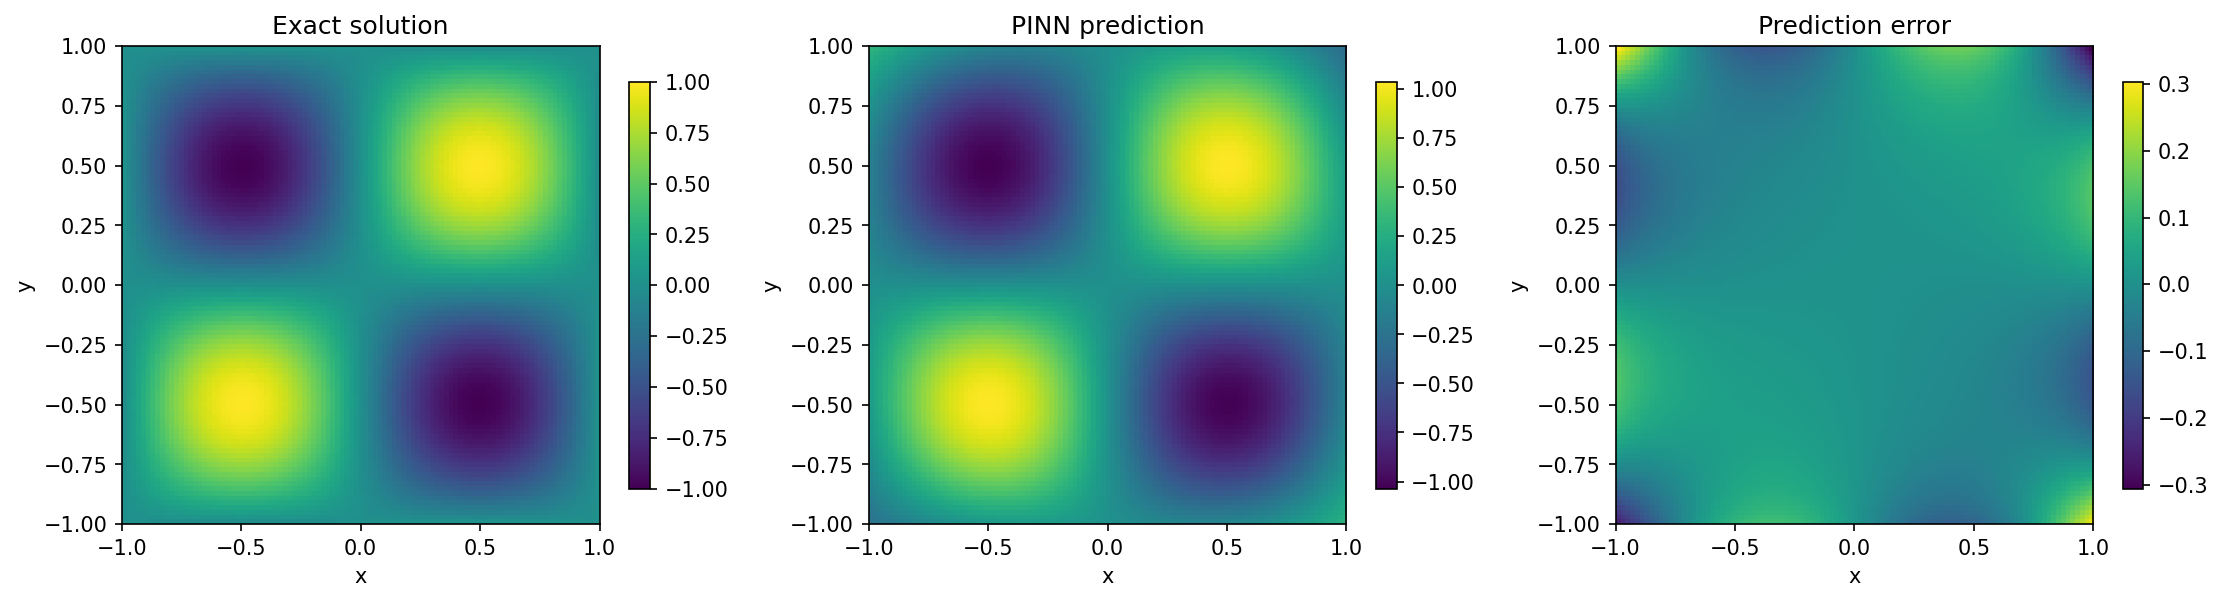

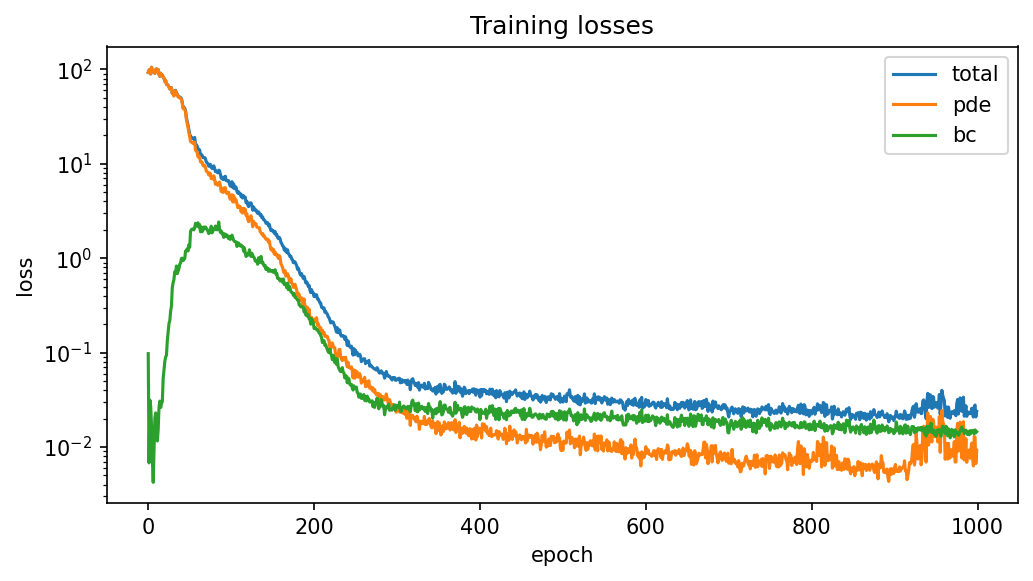

In [5]:
from IPython.display import Image, display

display(Image(filename='outputs/poisson_baseline_1k/poisson_fields.png'))
display(Image(filename='outputs/poisson_baseline_1k/training_losses.png'))

In [6]:
!python append_research_log.py --stage poisson-baseline --pde Poisson --setting "Omega=[-1,1]^2, epochs=1000, n_interior=1024, n_boundary=256" --changes "Ran baseline on Colab notebook" --done "Completed one Colab GPU run" --result "See outputs/poisson_baseline_1k/metrics.json" --next-step "Compare Colab runtime and error against the local baseline"

Appended entry to /content/PINNs/research_log.md


In [7]:
!cat research_log.md

# Research Log

## 2026-04-21

- Stage: planning
- PDE: Poisson boundary-value problem
- Problem setting: Omega = [-1,1] x [-1,1], exact solution u(x,y) = sin(pi x) sin(pi y), Dirichlet boundary condition u = 0, source term f(x,y) = 2 pi^2 sin(pi x) sin(pi y).
- Methods or changes: Started a local thesis workspace and added a baseline PINN implementation for the rectangular Poisson problem.
- What was done: Added baseline Poisson PINN code, plotting, metrics export, and a local persistent research log workflow in this project folder.
- Result: The project now has a concrete entry point for the first staged experiment.
- Open issue: Need to run the baseline training and verify convergence, runtime, and L2 error on this machine.
- Next step: Execute train_poisson_pinn.py, inspect outputs, and record the first actual run result.

## 2026-04-21

- Stage: setup
- PDE: Poisson
- Problem setting: Local workspace initialized in C:\Users\Admin\Desktop\ゼミ_AI\卒研
- Methods or changes: Added baseli